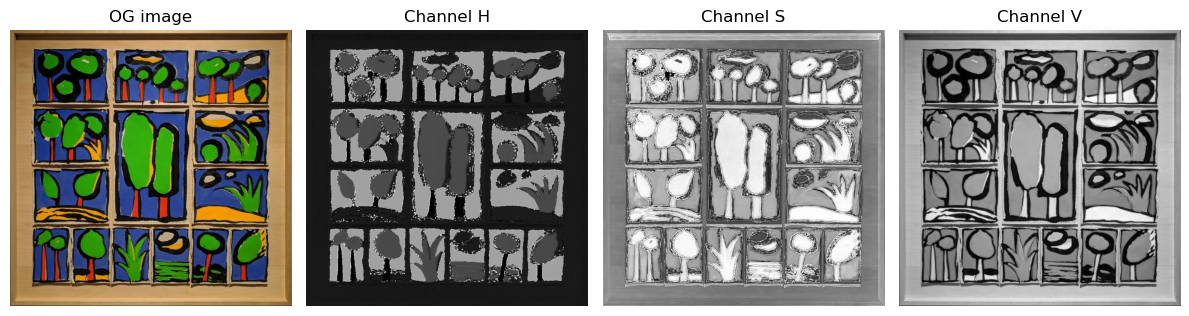

In [8]:
# lee una imagen de db y convierte a hsv y dame la imagen en cada canal
import cv2
import numpy as np
from matplotlib import pyplot as plt

# lee la imagen de la carpeta data/BBDD en el direcotio anterior
image = cv2.imread('../data/BBDD/BBDD_00043.jpg')
# EN LA MISMA FILA
# convierte la imagen de BGR a HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# separa los canales H, S, V
h_channel, s_channel, v_channel = cv2.split(hsv_image)
# muestra la imagen original y los canales H, S, V
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('OG image')
plt.axis('off')
plt.subplot(1, 4, 2)
plt.imshow(h_channel, cmap='gray')
plt.title('Channel H')
plt.axis('off')
plt.subplot(1, 4, 3)
plt.imshow(s_channel, cmap='gray')
plt.title('Channel S')
plt.axis('off')
plt.subplot(1, 4, 4)
plt.imshow(v_channel, cmap='gray')
plt.title('Channel V')
plt.axis('off')
plt.tight_layout()
plt.show()



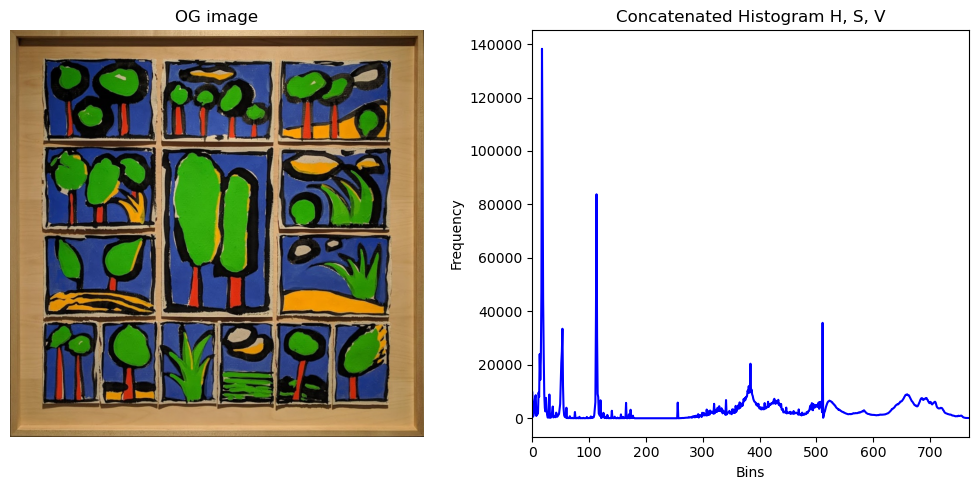

In [12]:
# Dame el histograma concatenado total de los 3 canales y primeor que se vea la imagen original
# calcula el histograma de cada canal   
hist_h = cv2.calcHist([h_channel], [0], None, [256], [0, 256])
hist_s = cv2.calcHist([s_channel], [0], None, [256], [0, 256])
hist_v = cv2.calcHist([v_channel], [0], None, [256], [0, 256])
# concatena los histogramas
hist_total = np.concatenate((hist_h, hist_s, hist_v), axis=0)
# muestra el histograma concatenado
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('OG image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.plot(hist_total, color='blue')
plt.title('Concatenated Histogram H, S, V')
plt.xlim([0, 768])
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
    

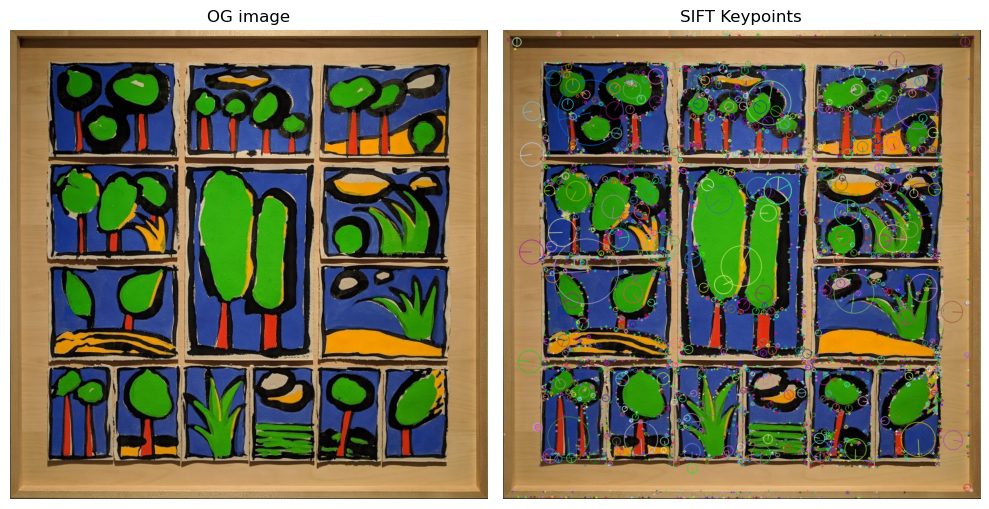

In [13]:
# haz lo mismo pero que se vea la imagen original y otra con los keypoints usando sift
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(image, None)
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('OG image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('SIFT Keypoints')
plt.axis('off')
plt.tight_layout()
plt.show()

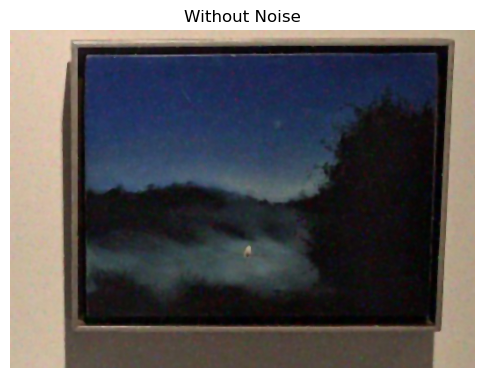

In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from utils.noise_removal_methods import main_noise_removal

# aplica esto a la imagen 10 de qsd2_w3, a la 12. hay que pasarle la imagena a la funcion
img_12_og = cv2.imread('../data/qsd2_w3/00012.jpg')
img_12_og = cv2.cvtColor(img_12_og, cv2.COLOR_BGR2RGB)

img_12 = main_noise_removal(img_12_og)
img_10_og = cv2.imread('../data/qsd2_w3/00010.jpg')
img_10_og = cv2.cvtColor(img_10_og, cv2.COLOR_BGR2RGB)
img_10 = main_noise_removal(img_10_og)

# muestra solo las proCESADA 10. sOLO 1 IMAGEN

# Mostrar solo la imagen procesada 10
plt.figure(figsize=(6,6))
plt.imshow(img_10)
plt.title("Without Noise")
plt.axis('off')
plt.show()


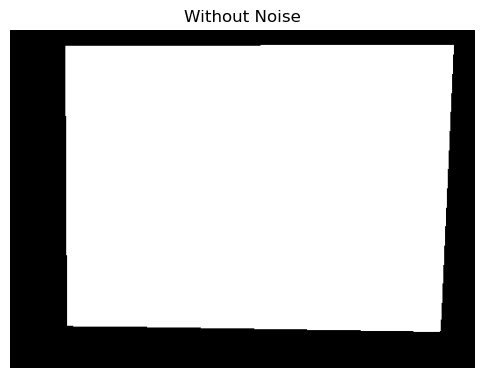

In [28]:
from background_removal.main_background_removal import main_background_removal

croped_img_10, mask = main_background_removal(img_10)

# muestra la mascara en blanco y negro
plt.figure(figsize=(6,6))
plt.imshow(mask, cmap='gray')
plt.title("Without Noise")
plt.axis('off')
plt.show()



In [29]:
# del qsd2_w3 lee el gt_corresps.pkl
import pickle
with open('../data/qsd2_w3/gt_corresps.pkl', 'rb') as f:
    gt_corresps = pickle.load(f)

gt_corresps

[[236],
 [107],
 [280, 285],
 [259],
 [86],
 [94, 132],
 [258, 35],
 [258, 35],
 [104, 130],
 [131],
 [282],
 [199, 34],
 [53, 124],
 [28],
 [260],
 [215],
 [163],
 [25],
 [30],
 [176, 128],
 [110],
 [7],
 [251],
 [183],
 [179],
 [270],
 [93],
 [200],
 [161],
 [182, 252]]